# Статистика, DS-поток
## Марафон-домашка SM.2, практическая часть

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Баллы за задание:**

* Задача 1 &mdash;  20 баллов
* Задача 2 &mdash;  20 баллов
* Задача 3 &mdash;  20 баллов
* Задача 4 &mdash;  50 баллов
* Задача 5 &mdash;  50 баллов

**Важность задач:**

* *высокая:* задачи 2, 3, 5;
* *средне-высокая:* задача 4;
* *обычная* задача 1.

Степень важности задач не связана с количеством баллов и определяется только на основе оценки полезности задачи с точки зрения усвоения текущего и дальнейшего материала. Например, если вы что-то не успеваете, рекомендуется в первую очередь выполнять более важные задачи.

In [1]:
# Bot check

# HW_ID: ds_sm2
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [2]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

sns.set(font_scale=1.5, palette="Set2")

RANDOM_STATE = 42
from typing import Any, Callable, List, Tuple

*Замечания.*
1. Вы должны помнить о разнице между оценкой / доверительным интервалом и *реализацией* оценки / доверительного интервала. На практике обычно слово *реализация* опускается.
2. Если оценка/интервал получен на лекции/семинаре, то нужно просто выписать формулу. Если такой случай не рассматривался, то нужно добавить его вывод.
3. Выборку надо сгенерировать один раз. Дело в том, что на практике при недостаточном размере выборки разумнее дособрать выборку, чем заново проводить все измерения.

---

### Задача 1. 

Пусть $X_1, ..., X_n$ &mdash; выборка из распределения $U[0, \theta]$. Рассмотрим оценки $X_{(n)}, \frac{n+1}{n}X_{(n)}, 2\overline{X}$ параметра $\theta$.

Какие из этих оценок являются несмещенными?

**Ответ:** $\frac{n+1}{n}X_{(n)}, 2\overline{X}$ - см. теор. д/з

Проведите практическое исследование несмещенности перечисленных оценок аналогично ислледованию несмещенности выборочной дисперсии в предыдущих заданиях. Разбор этой задачи для выборочной дисперсии был на занятии.

**Решение:**

In [4]:
BLUE = "#0077CC"
ORANGE = "#ec7c26"
VIOLET = "#bc13fe"

def estimate_Xn(X: np.ndarray) -> np.ndarray:
    """Смещенная оценка дисперсии"""
    return X.max(axis=1)

def estimate_Xn_corrected(X: np.ndarray) -> np.ndarray:
    """Смещенная оценка дисперсии"""
    n = X.shape[1]
    return ((n + 1) / n) * X.max(axis=1)


def estimate_2X(X: np.ndarray) -> np.ndarray:
    """Несмещенная оценка дисперсии"""
    return 2 * X.mean(axis=1)

In [5]:
estimators = [
    (estimate_Xn, r"$X_{(n)}$", ORANGE, 0.0),
    (estimate_Xn_corrected, r"$\frac{n+1}{n}X_{(n)}$", VIOLET, 0.1),
    (estimate_2X, r"$2\overline{X}$", BLUE, 0.2)
]

In [6]:
def est_plot(
    distribution: sps.rv_continuous,
    estimators: List[Tuple[Callable[[np.ndarray], np.ndarray], str, str, float]],
    sample_size: int,
    sample_count: int,
) -> None:
    """
    Построение графика разброса реализаций оценок и их средних значений.

    Аргументы:
        distribution: Распределение формата scipy.stats
        estimators: Список оценок и параметров для графиков (оценка, название, цвет, позиция_y)
        sample_size: Размер генерируемых выборок
        sample_count: Количество генерируемых выборок
    """

    X = distribution.rvs(size=(sample_count, sample_size))

    plt.figure(figsize=(18, 0.7 * len(estimators)))
    for estimator, name, color, y in estimators:
        E = estimator(X)

        plt.scatter(E, np.zeros(sample_count) + y, alpha=0.1, s=100, color=color, label=name)
        plt.scatter(E.mean(), y, marker="*", s=500, color="w", edgecolors="black")

    plt.vlines(1, -1, 1, color="r")
    plt.title("Размер выборки = %d" % sample_size)
    plt.yticks([])
    plt.legend()
    plt.xlim((0.6, 1.4))
    plt.ylim((-0.1, 0.1 * len(estimators)))

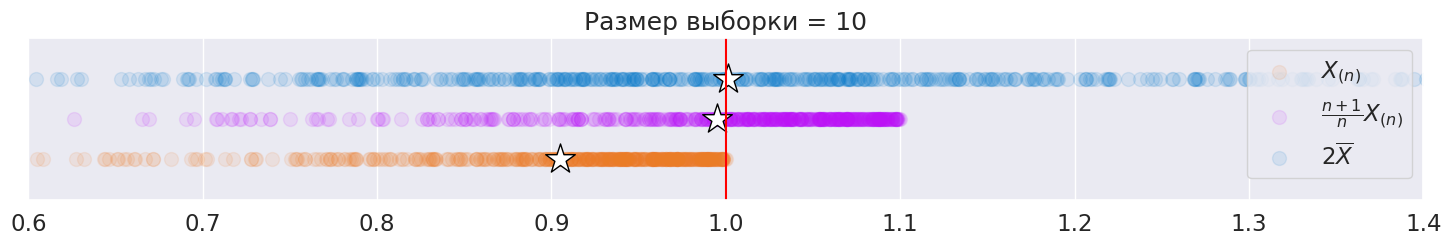

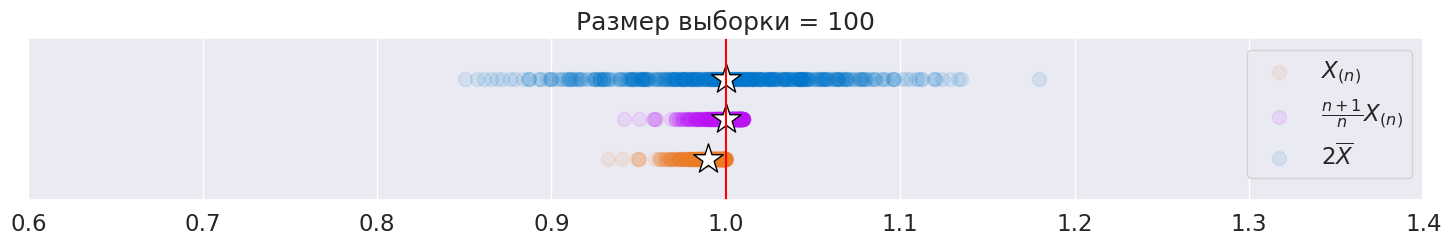

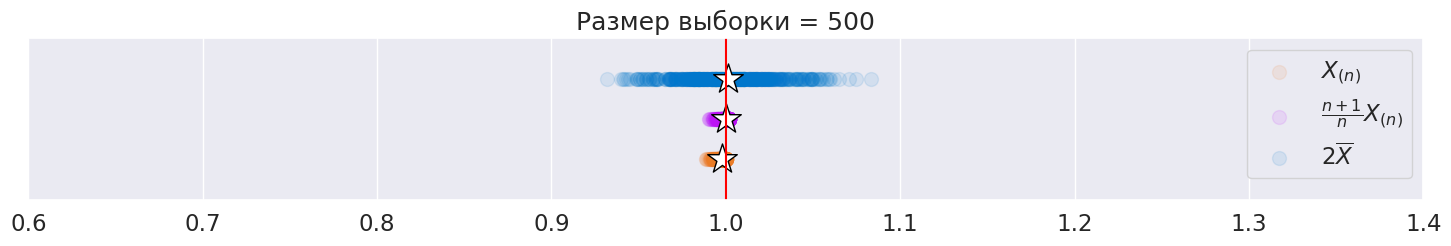

In [7]:
sample_size_list = (10, 100, 500)  # размеры выборок
sample_count = 500  # количество экспериментов

for sample_size in sample_size_list:
    est_plot(sps.uniform, estimators, sample_size, sample_count)

**Вывод:** Видим, сравнивая оранжевую состоятельную и смещённую оценку с двумя несмещёнными и состоятельными, что смещённость имеет значительный вклад только на выборках маленьких размеров. Так что важнее подобрать состоятельную оценку

---
### Задача 2.

Пусть $X_1, \ldots, X_n$ &mdash; выборка из распределения $\mathcal{N}(a, \sigma^2)$, причем $a$ не известно. Визуализируйте свойства состоятельности и асимптотической нормальности для оценки $S^2 = \overline{X^2} - \overline{X}^2$ дисперсии $\sigma^2$. 

Примеры кода можно посмотреть в материалах лекций. Обязательно на графике оценок визуализируйте границы, которые задает свойство асимптотической нормальности.

**Решение:**

In [83]:
size = 300
sample_count = 500

a, std = 10, 1 

n_range = np.arange(size) + 1
sample = sps.norm.rvs(size=(samples_count, size), loc=a, scale=std)
estimation = np.power(samples, 2).cumsum(axis=1) / n_range - np.power(samples.cumsum(axis=1) / n_range, 2)

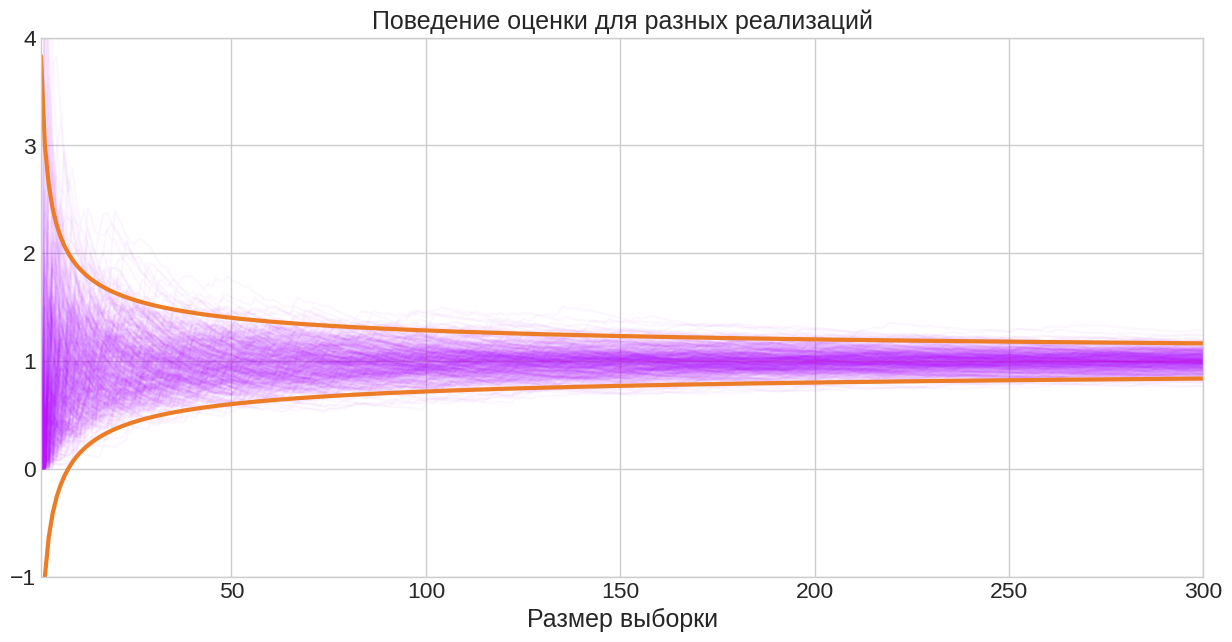

In [84]:
expect_deviation = 2 * std ** 2 / np.sqrt(n_range) * np.sqrt(2)

plt.style.use('seaborn-v0_8-whitegrid') 
plt.figure(figsize=(15, 7))
for i in range(sample_count):
    plt.plot(np.arange(size) + 1, estimation[i], color=VIOLET, alpha=0.03)
plt.plot(n_range, std ** 2 + expect_deviation, color=ORANGE, lw=3)
plt.plot(n_range, std ** 2 - expect_deviation, color=ORANGE, lw=3)
plt.title("Поведение оценки для разных реализаций")
plt.xlabel("Размер выборки");
plt.ylim((-1, 4))
plt.xlim((1, size));

**Вывод:** Оценка $S^2$ состоятельная и асимптотически нормальная для параметра $\sigma^2$ с асимптотической дисперсией $\sqrt{2}\sigma^2$

---
### Задача 3.

Пусть $X = (X_1, ..., X_n)$ &mdash; выборка из распределения $\mathcal{N}(a, \sigma^2)$, причем $a$ не известно. Визуализируйте асимптотический доверительный интервал Вальда для параметра дисперсии при росте размера выборки. 

Для этого сгенерируйте выборку $X_1, ... X_{N}, N = 100$ и постройте график доверительных интервалов уровня доверия $\alpha=0.95$, вычисленных для всех подвыборок размера $n$ вида $X_1, ... X_n$, $1 \le n \le 100$, используя написанную выше функцию. На график также нужно нанести точки выборки.

Чтобы не плодить код, напишите следующую функцию (см. ниже). При выборе стиля графика помните, что если изображаются лишь точки и линии, то лучше использовать серый фон, а если присутствуют закрашенные области, то предпочтительнее белый. Графики первого типа еще называют "легкими", а второго — "тяжелыми".

Для вычисления квантилей у каждого распределения из `scipy.stats` используйте функцию `ppf`.

**Решение:**

In [198]:
def draw_confidence_interval(
    left, right, estimation=None, sample=None, 
    ylim=(None, None), color_estimation=['#FF3300'], color_interval=['#00CC66'], 
    color_sample='#0066FF', label_estimation=['Оценка']
):
    '''
    Рисует доверительный интервал и оценку в зависимости от размера выборки.
    
    :param left: левые границы интервалов (в зависимости от n)
    :param right: правые границы интервалов (в зависимости от n)
    :param estimation: оценки (в зависимости от n)
    :param sample: выборка
    :param ylim: ограничение вертикальной оси
    :param color_estimation: цвет оценки
    :param color_interval: цвет интервала
    :param color_sample: цвет выборки
    :param label_estimation: подпись для оценки
    '''

    n_range = np.arange(left[0].size) + 1


    if sample is not None:
        plt.figure(figsize=(15, 7))
        plt.scatter(n_range, sample, color=color_sample, s=8, alpha=0.6)
        plt.title('Точки выборки $X$')
        plt.show()

    plt.figure(figsize=(15, 7))
    if estimation is not None:
        i = 0
        while i < len(estimation):
            estimation_i = estimation[i]
            color_estimation_i = color_estimation[i]
            label_estimation_i = label_estimation[i]
            plt.plot(n_range, estimation_i, color=color_estimation_i, lw=2, label=label_estimation_i)
            plt.scatter(n_range, estimation_i, color=color_estimation_i, s=10)
            i += 1

    i = 0
    while i < len(left):
        left_i = left[i]
        right_i = right[i]
        color_interval_i = color_interval[i]
        plt.plot(n_range[2:], left_i[2:], color=color_interval_i, lw=3, label=f'Нижняя граница {i + 1}-й оценки')
        plt.plot(n_range[2:], right_i[2:], color=color_interval_i, lw=3, label=f'Верхняя граница {i + 1}-й оценки')
        i += 1
    if ylim != (None, None):
        plt.ylim(ylim)
    plt.xlabel("Размер выборки")
    plt.legend()
    plt.show()

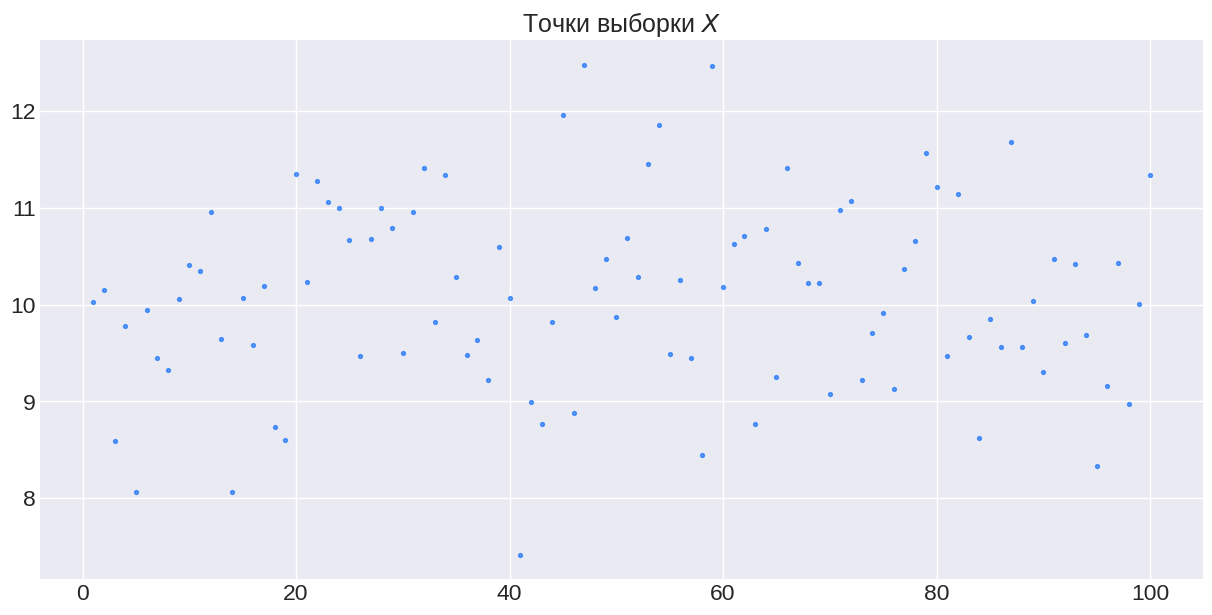

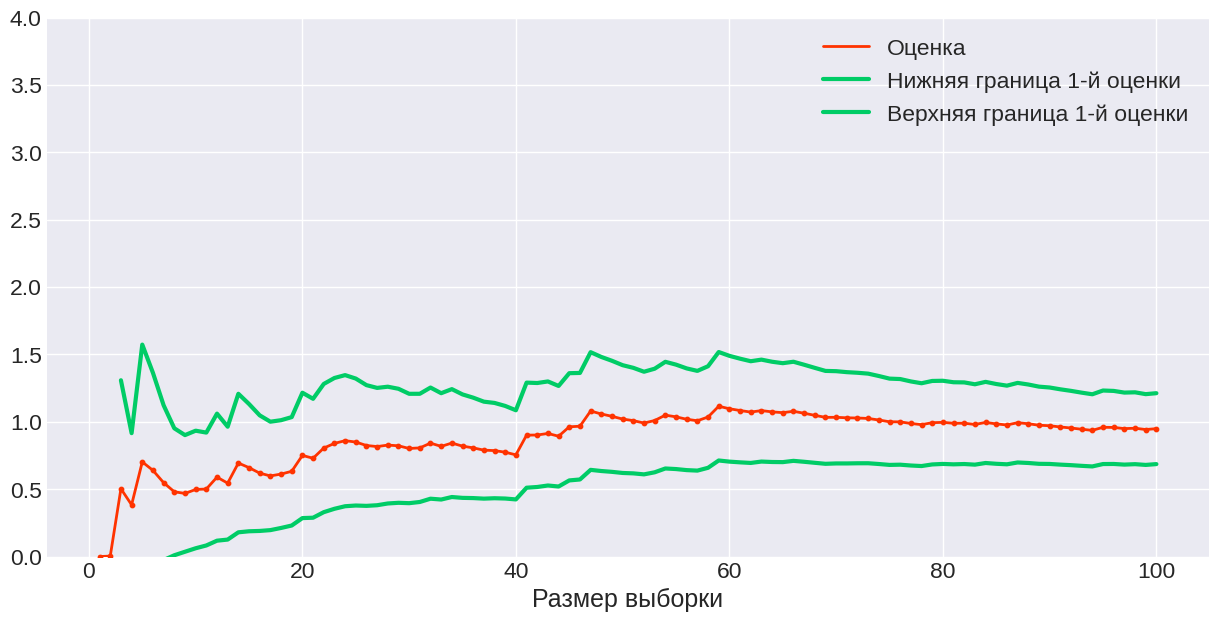

In [199]:
size = 100
n_range = np.arange(size) + 1

# a, std = 10, 1 
sample = sps.norm.rvs(size=size, loc=a, scale=std)

alpha = 0.95
z = sps.norm.ppf((1 + alpha) / 2)

estimation = np.power(sample, 2).cumsum() / n_range - np.power(sample.cumsum() / n_range, 2)
left = estimation + z * estimation * np.sqrt(2 / n_range)
right = estimation - z * estimation * np.sqrt(2 / n_range)

plt.style.use('seaborn-v0_8-darkgrid')
draw_confidence_interval(left=[left], right=[right], estimation=[estimation], sample=sample, ylim=(0, 4))

**Вывод:** Видим, что в случае подстановки состоятельной оценки в асимптотическую дисперсию доверительные интервалы сохраняют основные тендеции, а также покрывают оценку, однако становятся более шумными

_________________
### Задача 4.
Аналогично задаче 3 сгенерируйте выборку $X_1, ... X_{100}$ из распределения $\Gamma(3, 2)$ и постройте доверительные интервалы для следующих случаев:

* точный асимптотический доверительный интервал в параметрической модели $\Gamma(\theta, 2)$; точки выборки наносить на график не нужно;
* точный асимптотический доверительный интервал для $\theta$ в параметрической модели $\Gamma(\theta, \beta)$, причем $\beta$ неизвестно.

Изобразите интервалы *на одном* графике полупрозрачными цветами. Точки выборки наносить на график не нужно. 

/tmp/ipykernel_4138/822786485.py:11: RuntimeWarning: divide by zero encountered in divide
  estimation2 = (sample.cumsum() / n_range) / (np.power(sample, 2).cumsum() / n_range - np.power(sample.cumsum() / n_range, 2))
/tmp/ipykernel_4138/822786485.py:12: RuntimeWarning: divide by zero encountered in divide
  beta_est = np.power(sample.cumsum() / n_range, 2) / (np.power(sample, 2).cumsum() / n_range - np.power(sample.cumsum() / n_range, 2))
/tmp/ipykernel_4138/822786485.py:13: RuntimeWarning: invalid value encountered in divide
  left2 = estimation2 + z * estimation2 * np.sqrt(((2 * beta_est + 3) / beta_est) / n_range)
/tmp/ipykernel_4138/822786485.py:14: RuntimeWarning: invalid value encountered in divide
  right2 = estimation2 - z * estimation2 * np.sqrt(((2 * beta_est + 3) / beta_est) / n_range)


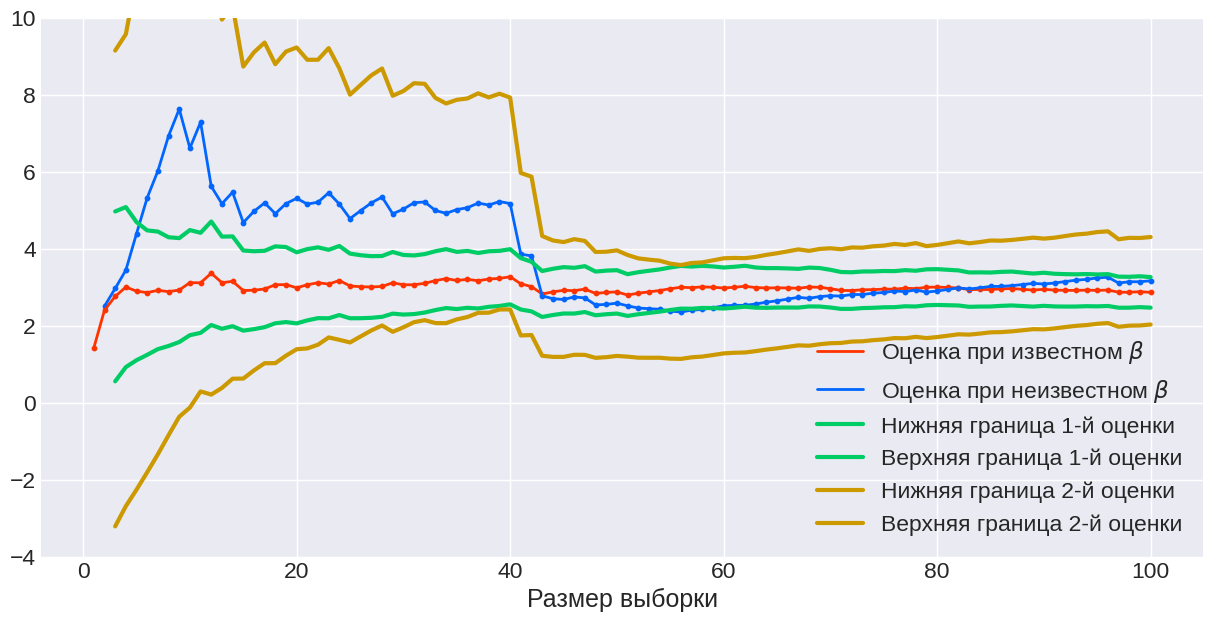

In [200]:
beta = 2
alpha = 3
size = 100
n_range = np.arange(size) + 1
sample = sps.gamma.rvs(a=beta, scale=1/alpha, size=size)

estimation1 = beta / (sample.cumsum() / n_range)
left1 = estimation1 + z * estimation1 / np.sqrt(2* n_range)
right1 = estimation1 - z * estimation1 / np.sqrt(2* n_range)

estimation2 = (sample.cumsum() / n_range) / (np.power(sample, 2).cumsum() / n_range - np.power(sample.cumsum() / n_range, 2))
beta_est = np.power(sample.cumsum() / n_range, 2) / (np.power(sample, 2).cumsum() / n_range - np.power(sample.cumsum() / n_range, 2))
left2 = estimation2 + z * estimation2 * np.sqrt(((2 * beta_est + 3) / beta_est) / n_range)
right2 = estimation2 - z * estimation2 * np.sqrt(((2 * beta_est + 3) / beta_est) / n_range)

draw_confidence_interval(left=[left1, left2], right=[right1, right2], estimation=[estimation1, estimation2], 
                         color_estimation = ['#FF3300', '#0066FF'],   
                         color_interval   = ['#00CC66', '#CC9900'],  
                         label_estimation=[r'Оценка при известном $\beta$', r'Оценка при неизвестном $\beta$'], 
                         ylim=(-4, 10))

Сравните полученные интервалы и поясните наблюдаемый эффект.

Не совсем корректно использовать выражение *«точный асимптотический доверительный интервал»*.  
Обычно *точный* интервал означает формулу, справедливую в конечной выборке,  
а *асимптотический* — приближённый интервал, выведенный из предельного распределения (например, через дельта-метод).  

В построенных графиках показаны именно асимптотические доверительные интервалы оценок.  
Видно, что при известном $\beta$ интервал для $\alpha$ заметно уже и менее шумный, чем при неизвестном $\beta$.  
Кроме того, при известном $\beta$ состоятельность оценки проявляется раньше (уже на меньших $n$).  

Это объясняется тем, что параметр $\beta$ в гамма-распределении влияет как на математическое ожидание,  
так и на дисперсию случайной величины $X \sim \Gamma(\beta, \alpha)$.  
Если $\beta$ неизвестен, его приходится оценивать по выборке, что добавляет дополнительную случайность.  
В результате неопределённость в оценке $\alpha$ возрастает, и доверительный интервал становится шире и более вариативным.


___
### Задача 5.

Пусть случайная величина $X$ имеет нормальное распределение с параметрами $(a, \sigma^2)$, то есть:
$$
X \sim \mathcal{N}(a, \sigma^2)
$$
Рассмотрим следующую задачу оптимизации:
$$
f(X) = (\mathsf{E}X-1)^2 + (\mathsf{D}X - 1)^2 \longrightarrow \min_{a, \sigma^2}
$$
В данном случае правильный ответ мы можем легко найти непосредственно, однако в реальности возникают гораздо более сложные функции, и решить задачу напрямую руками не представляется возможным. Для решения таких задач применяются различные градиентные методы, такие как, например, стохастический градиентный спуск. Оказывается, что в нём критически важно использовать несмещенные оценки градиента.

*Замечание.* Если смещение заключается только в том, что математическое ожидание оценки отличается от вектора градиента домножением каждой компоненты на одну и ту же константу, то проблем нет &mdash; все равно мы используем шаг градиента.

В данной задаче вам предлагается на примере простой функции убедиться, насколько важным оказывается использовать несмещенные оценки в итерационных процедурах.

**Решение:**

Запишите оптимальные значения параметров $a$ и $\sigma^2$, а также шаг простого градиентного спуска для минимизаци определенной выше функции $f(X)$:

$a$, $\sigma^2$ = 1, 1. $\theta_{t+1} = \theta_t - \eta \cdot (a - 1\ \ \sigma^2 - 1)^T$

Реализуйте метод простого градиентного спуска для выше описанной задачи оптимизации. Для каждой итерации сохраните текущие значения среднего и дисперсии, постройте график зависимости значений $a$ и $\sigma^2$ от шага процедуры. Наблюдается ли сходимость к оптимальным параметрам?

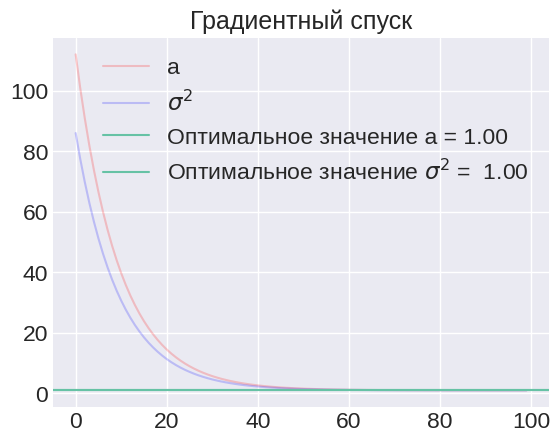

In [225]:
n = 100
params = np.zeros((n, 2))
params[0] = [112, 86]
eta = 0.1
n_range = np.arange(0, n)
for i in n_range[1:]:
    params[i] = params[i - 1] - eta * (params[i - 1] - 1)

plt.plot(n_range, params[:, 0], c='r', alpha=0.2, label='a')
plt.plot(n_range, params[:, 1], c='b', alpha=0.2, label=r'$\sigma^2$')
plt.axhline(params[-1, 0], label=rf'Оптимальное значение a = {params[-1, 0]:.2f}')
plt.axhline(params[-1, 1], label=rf'Оптимальное значение $\sigma^2$ =  {params[-1, 0]:.2f}')
plt.title('Градиентный спуск')
plt.legend();

Теперь предположим, что мы хотим оценить градиент стохастически. Например, давайте текущие значения среднего и дисперсии оценивать изученным ранее методом Монте-Карло. А именно, каждый раз мы будем генерировать выборку размера 5 из нормального распределения с текущими значениями параметров и далее по ней оценивать градиент.
Для оценки математического ожидания ипользуйте несмещенную оценку, а для дисперсии &mdash; смещенную. 

Реализуйте описанный выше подход. Как и прежде, изобразите текущие значения параметров в зависимости от итерации. Сошлась ли такая процедура к оптимальным значениям?

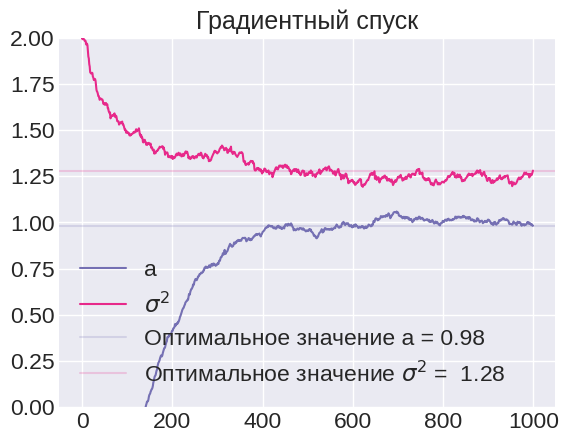

In [252]:
n = 1000
params = np.zeros((n, 2))
params[0] = [-3, 2]
eta = 0.01
n_range = np.arange(0, n)
for i in n_range[1:]:
    size = 5
    a, sig_sq = params[i - 1]
    x = sps.norm.rvs(loc=a, scale=np.sqrt(sig_sq), size=size)
    x_mean = x.mean()
    x_sq_sum = np.power(x, 2).sum()
    grad = np.array([x_mean - 1, 1 / size * np.power(x - x_mean, 2).sum() - 1])
    params[i] = params[i - 1] - eta * grad

plt.plot(n_range, params[:, 0], c='#7570b3', label='a')
plt.plot(n_range, params[:, 1], c='#e7298a', label=r'$\sigma^2$')
plt.axhline(params[-1, 0], label=rf'Оптимальное значение a = {params[-1, 0]:.2f}', color='#7570b3', alpha=0.2)
plt.axhline(params[-1, 1], label=rf'Оптимальное значение $\sigma^2$ =  {params[-1, 1]:.2f}', color='#e7298a', alpha=0.2)
plt.ylim(0, 2)
plt.title('Градиентный спуск')
plt.legend();

Теперь изменим нашу процедуру, взяв несмещенную оценку для дисперсии. Обратите внимание на параметр `ddof` в функции `np.var`. Поменялся ли результат?

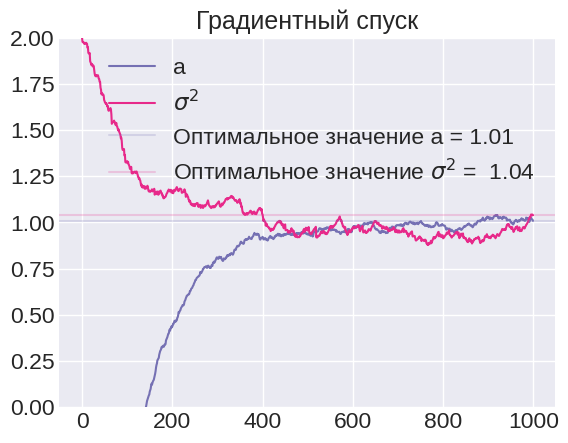

In [253]:
n = 1000
params = np.zeros((n, 2))
params[0] = [-3, 2]
eta = 0.01
n_range = np.arange(0, n)
for i in n_range[1:]:
    size = 5
    a, sig_sq = params[i - 1]
    x = sps.norm.rvs(loc=a, scale=np.sqrt(sig_sq), size=size)
    x_mean = x.mean()
    x_sq_sum = np.power(x, 2).sum()
    grad = np.array([x_mean - 1, 1 / (size - 1) * np.power(x - x_mean, 2).sum() - 1])
    params[i] = params[i - 1] - eta * grad

plt.plot(n_range, params[:, 0], c='#7570b3', label='a')
plt.plot(n_range, params[:, 1], c='#e7298a', label=r'$\sigma^2$')
plt.axhline(params[-1, 0], label=rf'Оптимальное значение a = {params[-1, 0]:.2f}', color='#7570b3', alpha=0.2)
plt.axhline(params[-1, 1], label=rf'Оптимальное значение $\sigma^2$ =  {params[-1, 1]:.2f}', color='#e7298a', alpha=0.2)
plt.ylim(0, 2)
plt.title('Градиентный спуск')
plt.legend();

**Вывод:** Да, значение стало сильно ближе к действительно оптимальному. Смещённая оценка очень колеблется, может сильно отклоняться

**Решение:**

Попрошу гпт векторизовать для быстрых вычислений и посчитать гистограммы для сигма

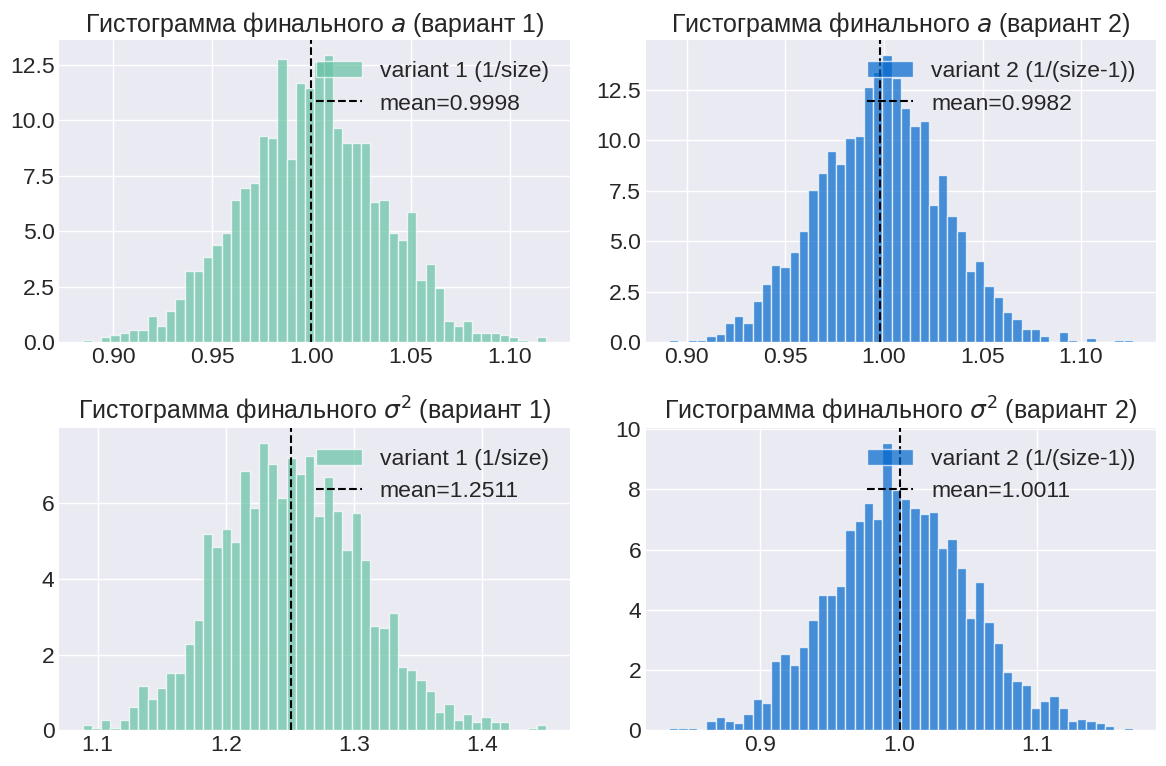

Параметры эксперимента: n = 1000 m_runs = 2000 size = 5 eta = 0.01

Variant 1 (1/size):
  final a: mean=0.9998, std=0.0352
  final sig^2: mean=1.2511, std=0.0546

Variant 2 (1/(size-1)):
  final a: mean=0.9982, std=0.0320
  final sig^2: mean=1.0011, std=0.0503


In [256]:
# Векторизованные сравнения двух вариантов градиента и гистограммы финальных параметров.
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sps

np.random.seed(2025)

# Параметры эксперимента
n = 1000        # число итераций
eta = 0.01
size = 5        # размер выборки на итерации
m_runs = 2000   # число параллельных независимых прогонов для оценки распределения финальных параметров

# Начальные параметры (одинаковые для обоих вариантов)
init_a = -3.0
init_sig_sq = 2.0

# Инициализация массивов параметров для двух вариантов градиента
params1 = np.zeros((m_runs, 2))  # вариант 1: grad1 = 1/size * sum((x-x_mean)^2) - 1
params2 = np.zeros((m_runs, 2))  # вариант 2: grad1 = 1/(size-1) * sum((x-x_mean)^2) - 1

params1[:, 0] = init_a
params1[:, 1] = init_sig_sq
params2[:, 0] = init_a
params2[:, 1] = init_sig_sq

# Основной итерационный цикл (векторизованно по прогону)
for i in range(1, n):
    # Для параметров первого варианта
    x1 = sps.norm.rvs(loc=params1[:, 0][:, None], scale=np.sqrt(params1[:, 1])[:, None], size=(m_runs, size))
    x1_mean = x1.mean(axis=1)
    grad0_1 = x1_mean - 1.0
    grad1_1 = (1.0/size) * np.sum((x1 - x1_mean[:, None])**2, axis=1) - 1.0   # изменение здесь
    grad1_full_1 = np.stack([grad0_1, grad1_1], axis=1)
    params1 = params1 - eta * grad1_full_1

    # Для параметров второго варианта
    x2 = sps.norm.rvs(loc=params2[:, 0][:, None], scale=np.sqrt(params2[:, 1])[:, None], size=(m_runs, size))
    x2_mean = x2.mean(axis=1)
    grad0_2 = x2_mean - 1.0
    grad1_2 = (1.0/(size - 1.0)) * np.sum((x2 - x2_mean[:, None])**2, axis=1) - 1.0  # и здесь
    grad1_full_2 = np.stack([grad0_2, grad1_2], axis=1)
    params2 = params2 - eta * grad1_full_2

# Соберём финальные значения
final_a_1 = params1[:, 0]
final_sig_sq_1 = params1[:, 1]
final_a_2 = params2[:, 0]
final_sig_sq_2 = params2[:, 1]

# Построим гистограммы (сравнение двух вариантов)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

bins = 50
axes[0,0].hist(final_a_1, bins=bins, density=True, alpha=0.7, label='variant 1 (1/size)')
axes[0,0].axvline(final_a_1.mean(), color='k', linestyle='--', label=f'mean={final_a_1.mean():.4f}')
axes[0,0].set_title(r'Гистограмма финального $a$ (вариант 1)')
axes[0,0].legend()

axes[0,1].hist(final_a_2, bins=bins, density=True, alpha=0.7, color='#0066CC', label='variant 2 (1/(size-1))')
axes[0,1].axvline(final_a_2.mean(), color='k', linestyle='--', label=f'mean={final_a_2.mean():.4f}')
axes[0,1].set_title(r'Гистограмма финального $a$ (вариант 2)')
axes[0,1].legend()

axes[1,0].hist(final_sig_sq_1, bins=bins, density=True, alpha=0.7, label='variant 1 (1/size)')
axes[1,0].axvline(final_sig_sq_1.mean(), color='k', linestyle='--', label=f'mean={final_sig_sq_1.mean():.4f}')
axes[1,0].set_title(r'Гистограмма финального $\sigma^2$ (вариант 1)')
axes[1,0].legend()

axes[1,1].hist(final_sig_sq_2, bins=bins, density=True, alpha=0.7, color='#0066CC', label='variant 2 (1/(size-1))')
axes[1,1].axvline(final_sig_sq_2.mean(), color='k', linestyle='--', label=f'mean={final_sig_sq_2.mean():.4f}')
axes[1,1].set_title(r'Гистограмма финального $\sigma^2$ (вариант 2)')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Числовая сводка
print("Параметры эксперимента: n =", n, "m_runs =", m_runs, "size =", size, "eta =", eta)
print("\nVariant 1 (1/size):")
print(f"  final a: mean={final_a_1.mean():.4f}, std={final_a_1.std(ddof=1):.4f}")
print(f"  final sig^2: mean={final_sig_sq_1.mean():.4f}, std={final_sig_sq_1.std(ddof=1):.4f}")

print("\nVariant 2 (1/(size-1)):")
print(f"  final a: mean={final_a_2.mean():.4f}, std={final_a_2.std(ddof=1):.4f}")
print(f"  final sig^2: mean={final_sig_sq_2.mean():.4f}, std={final_sig_sq_2.std(ddof=1):.4f}")


**Вывод:** Видим, что смещённая оценка действительно приводит к смещённому минимуму, а также к большей дисперсии этого минимума

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока